In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_style('whitegrid') 


 

Matplotlib is building the font cache; this may take a moment.


In [2]:
import os
os.listdir("../data")

['WA_Fn-UseC_-Telco-Customer-Churn.csv']

In [3]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("Veri seti boyutu (satır, sütun):", df.shape)
df.info()

Veri seti boyutu (satır, sütun): (7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  Paperless

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isnull().sum()

np.int64(11)

In [7]:
df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [8]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [10]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print("TotalCharges'ta eksik değer sayısı:", df['TotalCharges'].isnull().sum())

TotalCharges'ta eksik değer sayısı: 0


In [17]:
cat_cols = [col for col in df.columns if pd.api.types.is_string_dtype(df[col]) and col != 'customerID']
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

print("Kategorik değişkenler:", cat_cols)
print("\nSayısal değişkenler:", num_cols)

Kategorik değişkenler: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Sayısal değişkenler: ['tenure', 'MonthlyCharges', 'TotalCharges']


In [18]:
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df.groupby(col)['Churn'].mean().sort_values(ascending=False))


--- gender ---
gender
Female    0.269209
Male      0.261603
Name: Churn, dtype: float64

--- Partner ---
Partner
No     0.329580
Yes    0.196649
Name: Churn, dtype: float64

--- Dependents ---
Dependents
No     0.312791
Yes    0.154502
Name: Churn, dtype: float64

--- PhoneService ---
PhoneService
Yes    0.267096
No     0.249267
Name: Churn, dtype: float64

--- MultipleLines ---
MultipleLines
Yes                 0.286099
No                  0.250442
No phone service    0.249267
Name: Churn, dtype: float64

--- InternetService ---
InternetService
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: Churn, dtype: float64

--- OnlineSecurity ---
OnlineSecurity
No                     0.417667
Yes                    0.146112
No internet service    0.074050
Name: Churn, dtype: float64

--- OnlineBackup ---
OnlineBackup
No                     0.399288
Yes                    0.215315
No internet service    0.074050
Name: Churn, dtype: float64

--- DeviceProtection ---

In [14]:
df.groupby('Churn')[num_cols].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
0,37.569965,61.265124,2549.911442
1,17.979133,74.441332,1531.796094


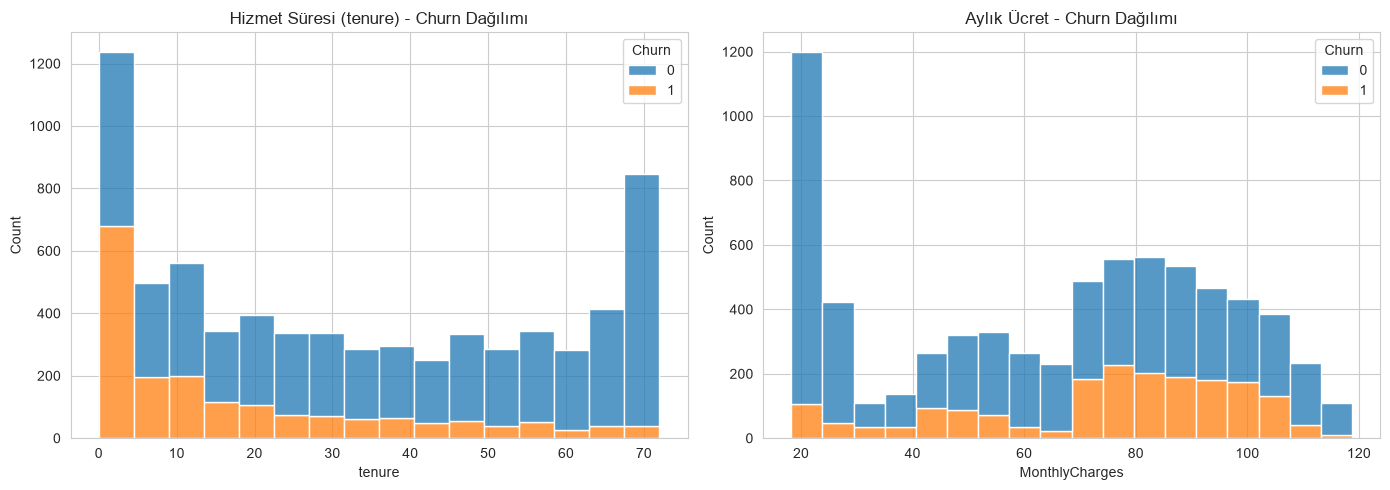

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', ax=axes[0])
axes[0].set_title('Hizmet Süresi (tenure) - Churn Dağılımı')
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', multiple='stack', ax=axes[1])
axes[1].set_title('Aylık Ücret - Churn Dağılımı')
plt.tight_layout()
plt.savefig('../gorseller/tenure_monthlycharges_churn.png', dpi=100)
plt.show()

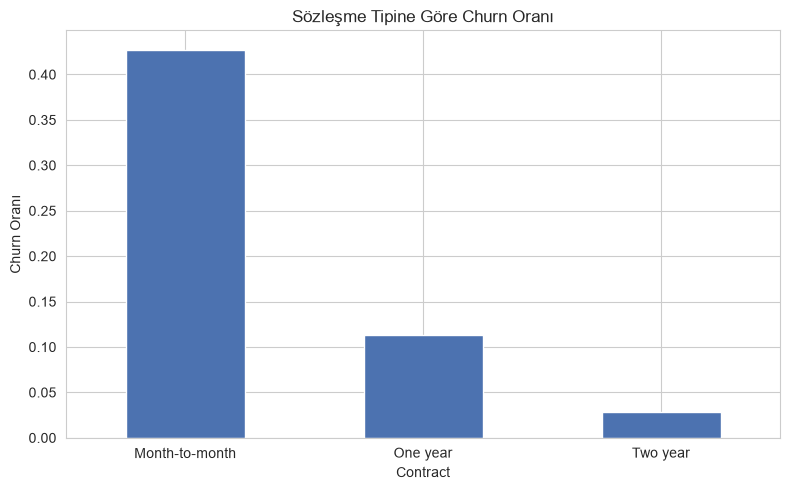

In [16]:
plt.figure(figsize=(8, 5))
df.groupby('Contract')['Churn'].mean().plot(kind='bar', color='#4C72B0')
plt.title('Sözleşme Tipine Göre Churn Oranı')
plt.ylabel('Churn Oranı')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../gorseller/contract_churn_orani.png', dpi=100)
plt.show()